In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install numba

In [3]:
import matplotlib.pyplot as plt
import numba
from numba import cuda
import numpy as np
import time

Image size: 256 x 256
Pixels count: 65536


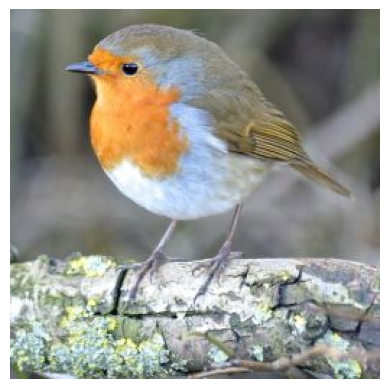

In [4]:
img = plt.imread('/content/drive/MyDrive/Dataset/HPC/bird.jpg')
h, w, _ = img.shape
pixelCount = h * w

print(f"Image size: {h} x {w}")
print(f"Pixels count: {pixelCount}")

plt.imshow(img)
plt.axis("off")
plt.show()


In [5]:
flatten_rgb = img.reshape(pixelCount, 3)

**CPU computation**

CPU time: 0.1841s


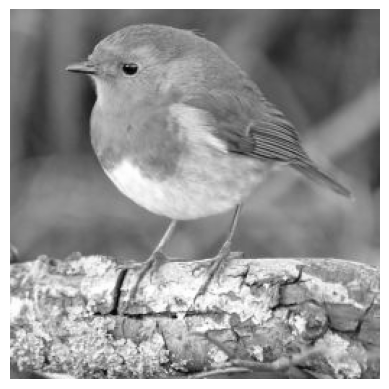

In [26]:
def rgb2gray_cpu(rgb, gray):
  for i in range(rgb.shape[0]):
    g = np.uint8((int(rgb[i, 0]) + int(rgb[i, 1]) + int(rgb[i, 2])) / 3)
    gray[i, 0] = gray[i, 1] = gray[i, 2] = g

gray_cpu = np.zeros((pixelCount, 3), np.uint8)
start = time.time()
hostDstCPU = rgb2gray_cpu(flatten_rgb, gray_cpu)
cpu_time = time.time() - start

print(f"CPU time: {cpu_time:.4f}s")
gray_cpu_img = gray_cpu.reshape(h, w, 3)

plt.imshow(gray_cpu_img)
plt.axis("off")
plt.savefig("gray_cpu.jpg", bbox_inches="tight")
plt.show()


**GPU computation**

GPU time with block size = 64: 0.0872s


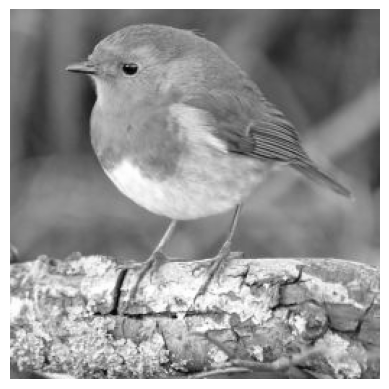

In [23]:
@cuda.jit
def rgb2gray_gpu(rgb, gray):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((rgb[tidx, 0] + rgb[tidx, 1] + rgb[tidx, 2]) / 3)
  gray[tidx, 0] = gray[tidx, 1] = gray[tidx, 2] = g

def grayscale_gpu(flatten_rgb, blockSize):
  gridSize = (pixelCount + blockSize - 1) // blockSize
  rgb_gpu = cuda.to_device(flatten_rgb)
  gray_gpu = cuda.device_array((pixelCount, 3), np.uint8)
  rgb2gray_gpu[gridSize, blockSize](rgb_gpu, gray_gpu)
  host_gray_gpu = gray_gpu.copy_to_host()
  return host_gray_gpu

blockSize = 64
start = time.time()
host_gray_gpu = grayscale_gpu(flatten_rgb, blockSize)
gpu_time = time.time() - start

print(f"GPU time with block size = {blockSize}: {gpu_time:.4f}s")
gray_gpu_img = host_gray_gpu.reshape(h, w, 3)

plt.imshow(gray_gpu_img)
plt.axis("off")
plt.savefig("gray_gpu.jpg", bbox_inches="tight")
plt.show()


**Experimenting with different block size**

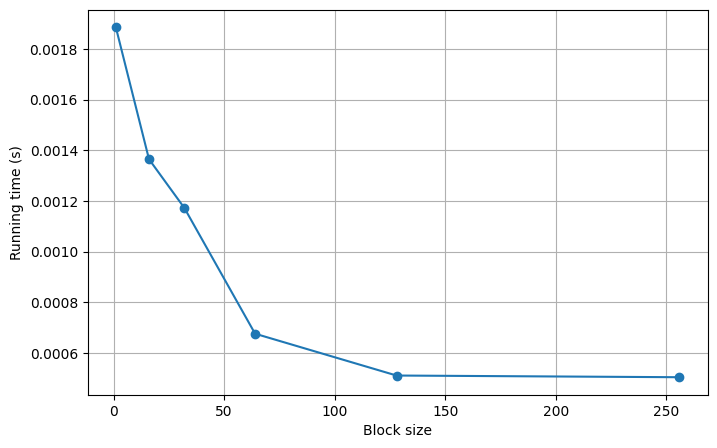

Best block size: 256 (0.000505 s)
Worst block size: 1 (0.001885 s)


In [14]:
BLOCK_SIZE = [1, 16, 32, 64, 128, 256]
running_times = []

for blockSize in BLOCK_SIZE:
  start = time.time()
  host_gray_gpu = grayscale_gpu(flatten_rgb, blockSize)
  running_times.append(time.time() - start)

plt.figure(figsize=(8, 5))
plt.plot(BLOCK_SIZE, running_times, marker="o")
plt.xlabel("Block size")
plt.ylabel("Running time (s)")
plt.grid(True)
plt.savefig("blocksize_vs_time.png", dpi=150, bbox_inches="tight")
plt.show()

best_bs = int(np.argmin(running_times))
worst_bs = int(np.argmax(running_times))

print(f"Best block size: {BLOCK_SIZE[best_bs]} ({running_times[best_bs]:.6f} s)")
print(f"Worst block size: {BLOCK_SIZE[worst_bs]} ({running_times[worst_bs]:.6f} s)")
